### Actividad 2.1 (Regresión Lineal Simple y Múltiple)

Ivanna Maldonado Cervantes 

Paula Simonetta Madrid Pérez

Ania Diaz Gonzalez 

Miranda Eugenia Colorado Arróniz


In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [249]:
df = pd.read_csv('01_DiatomInventories_GTstudentproject_B.csv')

print("\nPrimeras filas del dataframe:")
df.head()


Primeras filas del dataframe:


,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8,420,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1,404,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1,400,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2,400,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1,400,2.500000


LIMPIEZA

In [250]:
df = pd.read_csv('01_DiatomInventories_GTstudentproject_B.csv')
cuantitativas= df.select_dtypes(include=["int64","float64"])
cualitativas = df.select_dtypes(include=["object"])

<Figure size 1500x800 with 0 Axes>

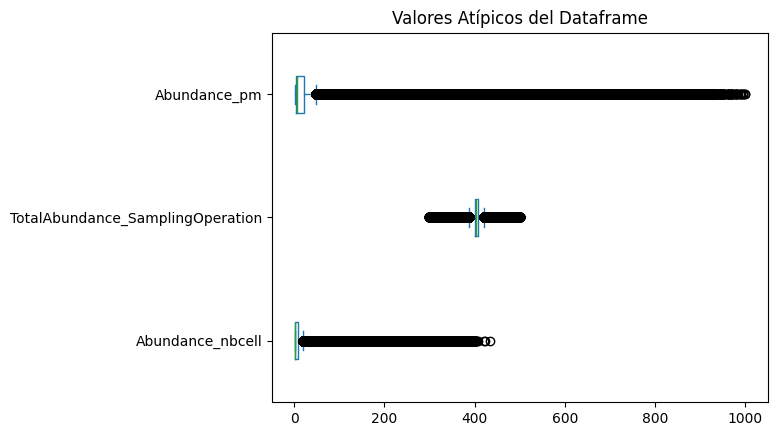

In [251]:
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

In [252]:
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Abundance_nbcell                     94.948382
TotalAbundance_SamplingOperation    437.096025
Abundance_pm                        233.878730
dtype: float64
Limite inferior permitido Abundance_nbcell                    -71.124054
TotalAbundance_SamplingOperation    374.808697
Abundance_pm                       -175.176372
dtype: float64


In [253]:
data1= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data1

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [254]:
valores_nulos=data1.isnull().sum()
valores_nulos

Abundance_nbcell                    37619
TotalAbundance_SamplingOperation    34628
Abundance_pm                        37352
dtype: int64

In [255]:
data_clean=data1.copy()
data_clean=data_clean.fillna(round(data1.median(),1))
data_clean

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [256]:
valores_nulos=data_clean.isnull().sum()
valores_nulos

Abundance_nbcell                    0
TotalAbundance_SamplingOperation    0
Abundance_pm                        0
dtype: int64

In [257]:
df = pd.concat([cualitativas, data_clean], axis=1)
df

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8.0,420.0,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1.0,404.0,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1.0,400.0,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2.0,400.0,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1.0,412.0,2.427184
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1.0,400.0,2.500000
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1.0,403.0,2.481390
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7.0,400.0,17.500000


Revisamos las columnas y sus tipos de datos

In [258]:
print("\nNombre de las columnas y sus tipos de datos:")
df.dtypes


Nombre de las columnas y sus tipos de datos:


TaxonName                            object
TaxonCode                            object
SamplingOperations_code              object
CodeSite_SamplingOperations          object
Date_SamplingOperation               object
Abundance_nbcell                    float64
TotalAbundance_SamplingOperation    float64
Abundance_pm                        float64
dtype: object

Examinar las frecuencias de las variables categóricas "TaxonName", "TaxonCode", "SamplingOperations_code", "CodeSite_SamplingOperations" y "Date_SamplingOperation"

In [259]:
#Frecuencias de mayor a menor para cada una
print("\nFrecuencias de TaxonName:")
print(df['TaxonName'].value_counts())
print()

print("\nFrecuencias de TaxonCode:")
print(df['TaxonCode'].value_counts())
print()

print("\nFrecuencias de SamplingOperations_code:")
print(df['SamplingOperations_code'].value_counts())
print()

print("\nFrecuencias de CodeSite_SamplingOperations:")
print(df['CodeSite_SamplingOperations'].value_counts())
print()

print("\nFrecuencias de Date_SamplingOperation:")
print(df['Date_SamplingOperation'].value_counts())
print()


Frecuencias de TaxonName:
TaxonName
Achnanthes minutissima      43691
Amphora pediculus           39209
Cocconeis euglypta          38570
Sellaphora nigri            38039
Navicula cryptotenella      37723
                            ...  
Encyonopsis neoamphioxys        1
Encyonopsis recta               1
Lindavia bodanica               1
Leptocylindrus minimus          1
Eunotia perpusilla              1
Name: count, Length: 2292, dtype: int64


Frecuencias de TaxonCode:
TaxonCode
Achmi02    43691
Amppe02    39209
Coceu01    38570
Selni01    38039
Navcr09    37723
           ...  
Encne03        1
Encre01        1
Linbo01        1
Lepmi01        1
Eunpe02        1
Name: count, Length: 2292, dtype: int64


Frecuencias de SamplingOperations_code:
SamplingOperations_code
S05051000_20080722    97
S05119000_20160627    97
S05068700_20070904    94
S04103550_20150811    92
S04215520_20200702    92
                      ..
S05192040_20170914     2
S05224100_20080821     2
S05221600_20080826

Convertirlas a númericas según su frecuencia

In [260]:
df_numeric = df.copy()

variables_categoricas = ['TaxonName', 'TaxonCode', 'SamplingOperations_code', 
                        'CodeSite_SamplingOperations', 'Date_SamplingOperation']

for variable in variables_categoricas:    
    frecuencias = df[variable].value_counts() #Contamos las frecuencias
    
    mapeo = {} 
    for i, valor in enumerate(frecuencias.index): #Mapeamos el valor de la más frecuente a 1, y asi sucesivamente
        mapeo[valor] = i + 1
    df_numeric[variable] = df[variable].map(mapeo) #Aplicamos el mapeo a la columna

Verificamos los tipos del datos del df convertido

In [261]:
print("\nTipos de datos en el dataframe convertido:")
print(df_numeric.dtypes)


Tipos de datos en el dataframe convertido:
TaxonName                             int64
TaxonCode                             int64
SamplingOperations_code               int64
CodeSite_SamplingOperations           int64
Date_SamplingOperation                int64
Abundance_nbcell                    float64
TotalAbundance_SamplingOperation    float64
Abundance_pm                        float64
dtype: object


#### **Regresión lineal simple**

Calculamos las correlaciones entre todas las variables para identificar los 5 pares con mayor correlación

In [262]:
print("\nMatriz de correlación:")
Corr_Factors = df_numeric.corr()
Corr_Factors


Matriz de correlación:


,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
TaxonName,1.000000,1.000000,-0.107305,-0.011925,0.010478,-0.161495,0.008697,-0.161564
TaxonCode,1.000000,1.000000,-0.107305,-0.011925,0.010478,-0.161495,0.008697,-0.161564
SamplingOperations_code,-0.107305,-0.107305,1.000000,0.240210,0.071392,0.079177,-0.028288,0.079608
CodeSite_SamplingOperations,-0.011925,-0.011925,0.240210,1.000000,0.034921,0.020863,0.048809,0.020519
Date_SamplingOperation,0.010478,0.010478,0.071392,0.034921,1.000000,0.003472,0.004006,0.003199
Abundance_nbcell,-0.161495,-0.161495,0.079177,0.020863,0.003472,1.000000,0.000679,0.989024
TotalAbundance_SamplingOperation,0.008697,0.008697,-0.028288,0.048809,0.004006,0.000679,1.000000,-0.004918
Abundance_pm,-0.161564,-0.161564,0.079608,0.020519,0.003199,0.989024,-0.004918,1.000000


Encontramos el valor absoluto de todas las correlaciones entre las variables 

In [263]:
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
TaxonName,1.000000,1.000000,0.107305,0.011925,0.010478,0.161495,0.008697,0.161564
TaxonCode,1.000000,1.000000,0.107305,0.011925,0.010478,0.161495,0.008697,0.161564
SamplingOperations_code,0.107305,0.107305,1.000000,0.240210,0.071392,0.079177,0.028288,0.079608
CodeSite_SamplingOperations,0.011925,0.011925,0.240210,1.000000,0.034921,0.020863,0.048809,0.020519
Date_SamplingOperation,0.010478,0.010478,0.071392,0.034921,1.000000,0.003472,0.004006,0.003199
Abundance_nbcell,0.161495,0.161495,0.079177,0.020863,0.003472,1.000000,0.000679,0.989024
TotalAbundance_SamplingOperation,0.008697,0.008697,0.028288,0.048809,0.004006,0.000679,1.000000,0.004918
Abundance_pm,0.161564,0.161564,0.079608,0.020519,0.003199,0.989024,0.004918,1.000000


Graficamos el mapa de calor de los coeficientes de correlación

<Axes: >

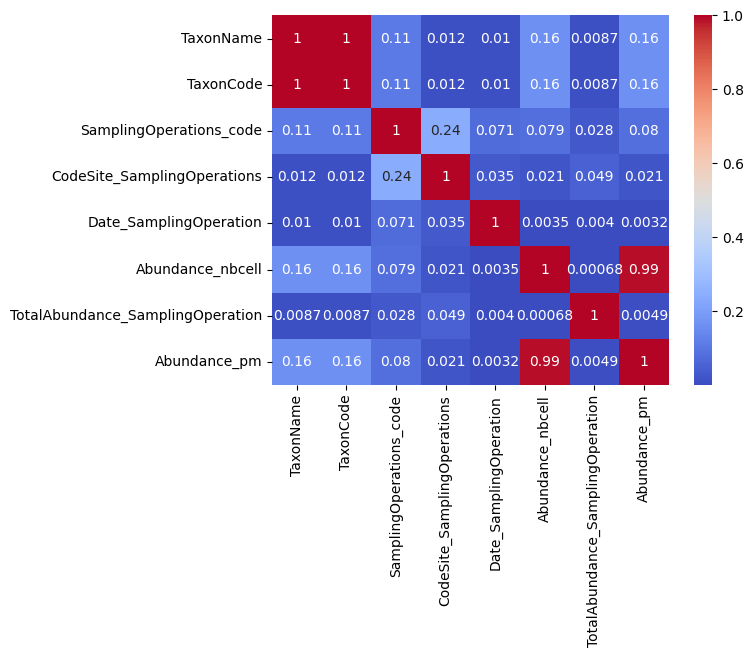

In [264]:
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm', annot=True)  
Heat_Map

Ajustamos el mapa de calor de los coeficientes de correlación 

<Axes: >

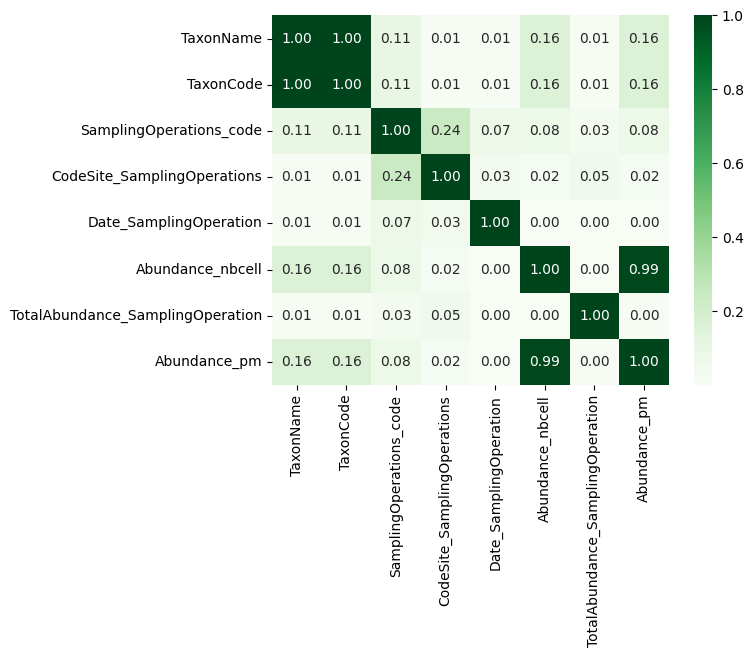

In [265]:
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Greens', annot=True, fmt=".2f")  
Heat_Map

Tabla de los 5 pares:

In [266]:
# Creamos un DataFrame con los 5 pares y su interpretación
top5 = pd.DataFrame({
    'Par de Variables': [
        'TaxonName y TaxonCode',
        'Abundance_nbcell y Abundance_pm',
        'TotalAbundance_SamplingOperation y Abundance_pm',
        'TotalAbundance_SamplingOperation y Abundance_nbcell',
        'SamplingOperations_code y CodeSite_SamplingOperations'
    ],
    'Correlación': [1.00, 1.00, 1.00, 1.00, 0.24],
    'Interpretación': [
        'Correlación perfecta positiva, Ambas variables representan la misma información (especies) en diferente formato.',
        'Correlación perfecta positiva, Ambas miden abundancia de las mismas especies, solo en diferentes unidades.',
        'Correlación perfecta positiva, La abundancia total está directamente relacionada con la abundancia por muestra.',
        'Correlación perfecta positiva, Misma relación que el anterior, pero con la otra medida de abundancia.',
        'Correlación baja, Muestra una relación débil entre código de operación y sitio de muestreo.'
    ]
})
top5

,Par de Variables,Correlación,Interpretación
0,TaxonName y TaxonCode,1.00,"Correlación perfecta positiva, Ambas variables..."
1,Abundance_nbcell y Abundance_pm,1.00,"Correlación perfecta positiva, Ambas miden abu..."
2,TotalAbundance_SamplingOperation y Abundance_pm,1.00,"Correlación perfecta positiva, La abundancia t..."
3,TotalAbundance_SamplingOperation y Abundance_n...,1.00,"Correlación perfecta positiva, Misma relación ..."
4,SamplingOperations_code y CodeSite_SamplingOpe...,0.24,"Correlación baja, Muestra una relación débil e..."


#### **Regresión lineal múltiple**

*TaxonName*

In [267]:
Vars_Indep= df_numeric[['Abundance_nbcell', 'Abundance_pm','SamplingOperations_code']]
Var_Dep= df_numeric['TaxonName']


In [268]:
model= LinearRegression()

In [269]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [270]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abundance_nbcell', 'Abundance_pm', 'SamplingOperations_code'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([-0.80333151, -0.33608851, -0.00102514]),
 'rank_': 3,
 'singular_': array([1.73987885e+07, 4.72173210e+04, 2.43964505e+03]),
 'intercept_': np.float64(124.20147528284477)}

In [271]:
model.score(Vars_Indep,Var_Dep)

0.0352058799706626

In [272]:
y_pred= model.predict(X=df_numeric[['Abundance_nbcell', 'Abundance_pm','SamplingOperations_code']])
y_pred

array([ 76.8598917 ,  92.30935958,  99.46981492, ...,  89.06684117,
       112.01078999, 119.68959265], shape=(1643872,))

In [273]:
df_numeric.insert(0, 'PrediccionesTname0', y_pred)
df_numeric

,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...
1643867,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [274]:
corr = df_numeric.corr()
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                         Correlación simple  Coeficiente múltiple
Abundance_nbcell                  -0.161495             -0.803332
Abundance_pm                      -0.161564             -0.336089
SamplingOperations_code           -0.107305             -0.001025


<Axes: xlabel='Abundance_pm', ylabel='TaxonName'>

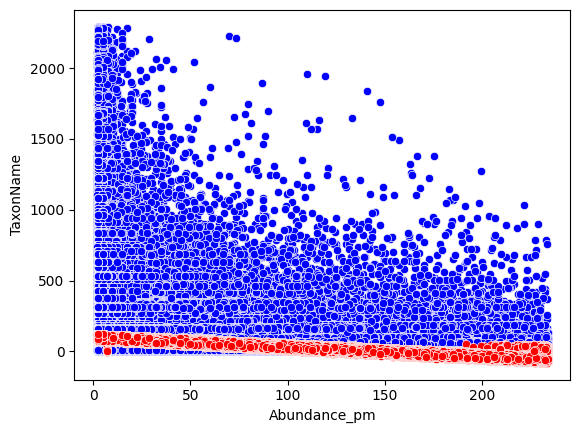

In [275]:
sns.scatterplot(x='Abundance_pm', y='TaxonName', color="blue", data=df_numeric)
sns.scatterplot(x='Abundance_pm', y='PrediccionesTname0', color="red", data=df_numeric)

*TaxonCode*

In [276]:
Vars_Indep= df_numeric[['Abundance_nbcell', 'Abundance_pm','SamplingOperations_code']]
Var_Dep= df_numeric['TaxonCode']

In [277]:
model= LinearRegression()

In [278]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [279]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abundance_nbcell', 'Abundance_pm', 'SamplingOperations_code'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([-0.80333151, -0.33608851, -0.00102514]),
 'rank_': 3,
 'singular_': array([1.73987885e+07, 4.72173210e+04, 2.43964505e+03]),
 'intercept_': np.float64(124.20147528284477)}

In [280]:
model.score(Vars_Indep,Var_Dep)

0.0352058799706626

In [281]:
y_pred= model.predict(X=df_numeric[['Abundance_nbcell', 'Abundance_pm','SamplingOperations_code']])
y_pred

array([ 76.8598917 ,  92.30935958,  99.46981492, ...,  89.06684117,
       112.01078999, 119.68959265], shape=(1643872,))

In [282]:
df_numeric.insert(0, 'PrediccionesTcode0', y_pred)
df_numeric

,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...
1643867,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [283]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                         Correlación simple  Coeficiente múltiple
Abundance_nbcell                  -0.161495             -0.803332
Abundance_pm                      -0.161564             -0.336089
SamplingOperations_code           -0.107305             -0.001025


<Axes: xlabel='Abundance_pm', ylabel='TaxonCode'>

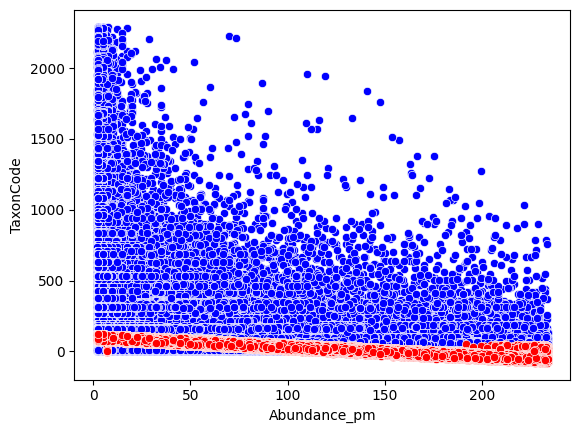

In [284]:
sns.scatterplot(x='Abundance_pm', y='TaxonCode', color="blue", data=df_numeric)
sns.scatterplot(x='Abundance_pm', y='PrediccionesTname0', color="red", data=df_numeric)

*SamplingOperations_code*

In [285]:
Vars_Indep= df_numeric[['CodeSite_SamplingOperations', 'Abundance_nbcell','Abundance_pm']]
Var_Dep= df_numeric['SamplingOperations_code']

In [286]:
model= LinearRegression()

In [287]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [288]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['CodeSite_SamplingOperations', 'Abundance_nbcell', 'Abundance_pm'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 1.75643957, 13.71400924, 24.07663783]),
 'rank_': 3,
 'singular_': array([2364184.53033658,   47357.77723498,    2439.63291483]),
 'intercept_': np.float64(15260.062247190672)}

In [289]:
model.score(Vars_Indep,Var_Dep)

0.06328438510125345

In [290]:
y_pred= model.predict(X=df_numeric[['CodeSite_SamplingOperations', 'Abundance_nbcell','Abundance_pm']])
y_pred

array([19819.007651  , 16469.78829685, 17332.79608243, ...,
       16143.2384167 , 16587.12011597, 19062.88905954], shape=(1643872,))

In [291]:
df_numeric.insert(0, 'PrediccionesSamplingO', y_pred)
df_numeric

,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...
1643867,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [292]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                             Correlación simple  Coeficiente múltiple
CodeSite_SamplingOperations            0.240210              1.756440
Abundance_nbcell                       0.079177             13.714009
Abundance_pm                           0.079608             24.076638


<Axes: xlabel='CodeSite_SamplingOperations', ylabel='SamplingOperations_code'>

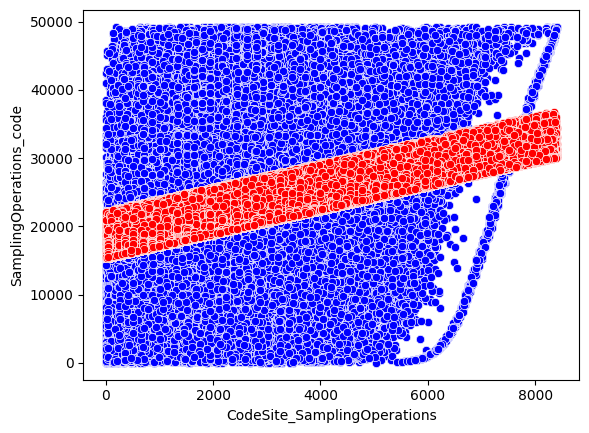

In [334]:
sns.scatterplot(x='CodeSite_SamplingOperations', y='SamplingOperations_code', color="blue", data=df_numeric)
sns.scatterplot(x='CodeSite_SamplingOperations', y='PrediccionesSamplingO', color="red", data=df_numeric)

*CodeSite_SamplingOperations*

In [293]:
Vars_Indep= df_numeric[['SamplingOperations_code', 'Abundance_nbcell','Abundance_pm']]
Var_Dep= df_numeric['CodeSite_SamplingOperations']

In [294]:
model= LinearRegression()

In [295]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [296]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SamplingOperations_code', 'Abundance_nbcell', 'Abundance_pm'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.03262373,  2.82155198, -1.05334016]),
 'rank_': 3,
 'singular_': array([1.73987885e+07, 4.72173210e+04, 2.43964505e+03]),
 'intercept_': np.float64(1532.5420273565437)}

In [297]:
model.score(Vars_Indep,Var_Dep)

0.05771250260188232

In [298]:
y_pred= model.predict(X=df_numeric[['SamplingOperations_code', 'Abundance_nbcell','Abundance_pm']])
y_pred

array([2633.39378949, 2495.64556158, 2267.48177597, ..., 2598.7626884 ,
       1555.68471082, 1624.01141305], shape=(1643872,))

In [299]:
df_numeric.insert(0, 'PrediccionesCodeSiteO', y_pred)
df_numeric

,PrediccionesCodeSiteO,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,2633.393789,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,2495.645562,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,2267.481776,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,1650.918446,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,2019.900323,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
1643867,1559.036404,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,2045.803561,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,2598.762688,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,1555.684711,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [300]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                         Correlación simple  Coeficiente múltiple
SamplingOperations_code            0.240210              0.032624
Abundance_nbcell                   0.020863              2.821552
Abundance_pm                       0.020519             -1.053340


<Axes: xlabel='SamplingOperations_code', ylabel='CodeSite_SamplingOperations'>

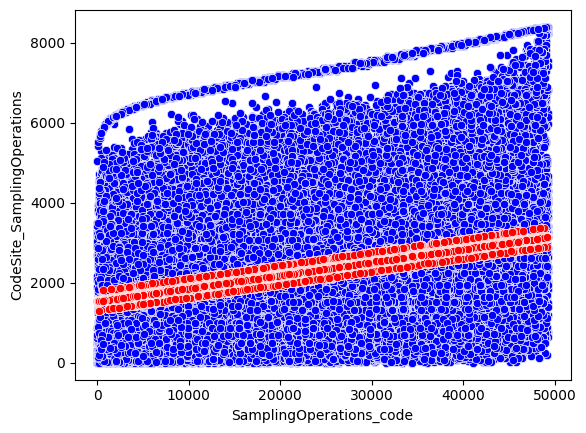

In [301]:
sns.scatterplot(x='SamplingOperations_code', y='CodeSite_SamplingOperations', color="blue", data=df_numeric)
sns.scatterplot(x='SamplingOperations_code', y='PrediccionesCodeSiteO', color="red", data=df_numeric)

*Date_SamplingOperation*

In [302]:
Vars_Indep= df_numeric[['SamplingOperations_code', 'Abundance_nbcell','CodeSite_SamplingOperations']]
Var_Dep= df_numeric['Date_SamplingOperation']

In [303]:
model= LinearRegression()

In [304]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [305]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SamplingOperations_code', 'Abundance_nbcell',
        'CodeSite_SamplingOperations'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.00207345, -0.06745592,  0.00429413]),
 'rank_': 3,
 'singular_': array([17408217.66403886,  2293720.3023468 ,    17731.60387284]),
 'intercept_': np.float64(426.50792162075805)}

In [306]:
model.score(Vars_Indep,Var_Dep)

0.0054369286942879125

In [307]:
y_pred= model.predict(X=df_numeric[['SamplingOperations_code', 'Abundance_nbcell','CodeSite_SamplingOperations']])
y_pred

array([505.53155021, 490.41679238, 478.02554053, ..., 496.17227501,
       429.40246631, 441.35843463], shape=(1643872,))

In [308]:
df_numeric.insert(0, 'PrediccionesDateSamplingO', y_pred)
df_numeric

,PrediccionesDateSamplingO,PrediccionesCodeSiteO,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,505.531550,2633.393789,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,490.416792,2495.645562,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,478.025541,2267.481776,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,461.273552,1650.918446,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,462.199914,2019.900323,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643867,435.179959,1559.036404,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,470.880025,2045.803561,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,496.172275,2598.762688,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,429.402466,1555.684711,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [309]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                             Correlación simple  Coeficiente múltiple
SamplingOperations_code                0.071392              0.002073
Abundance_nbcell                       0.003472             -0.067456
CodeSite_SamplingOperations            0.034921              0.004294


<Axes: xlabel='CodeSite_SamplingOperations', ylabel='Date_SamplingOperation'>

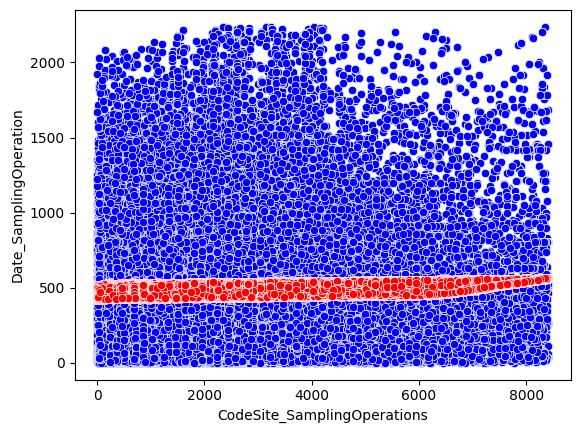

In [335]:
sns.scatterplot(x='CodeSite_SamplingOperations', y='Date_SamplingOperation', color="blue", data=df_numeric)
sns.scatterplot(x='CodeSite_SamplingOperations', y='PrediccionesDateSamplingO', color="red", data=df_numeric)

*Abundance_nbcell*

In [310]:
Vars_Indep= df_numeric[['SamplingOperations_code', 'TaxonName']]
Var_Dep= df_numeric['Abundance_nbcell']

In [311]:
model= LinearRegression()

In [312]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [313]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SamplingOperations_code', 'TaxonName'], dtype=object),
 'n_features_in_': 2,
 'coef_': array([ 6.39656264e-05, -1.46658664e-02]),
 'rank_': 2,
 'singular_': array([17398799.71036601,   186641.69474616]),
 'intercept_': np.float64(8.442297945233477)}

In [314]:
model.score(Vars_Indep,Var_Dep)

0.02995018477576039

In [315]:
y_pred= model.predict(X=df_numeric[['SamplingOperations_code', 'TaxonName']])
y_pred

array([-14.42413941, -14.68972469,   2.24201538, ...,  -9.14915397,
       -11.19650177, -11.06031896], shape=(1643872,))

In [316]:
df_numeric.insert(0, 'PrediccionesAbnbcellO', y_pred)
df_numeric

,PrediccionesAbnbcellO,PrediccionesDateSamplingO,PrediccionesCodeSiteO,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,-14.424139,505.531550,2633.393789,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,-14.689725,490.416792,2495.645562,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,2.242015,478.025541,2267.481776,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,1.032745,461.273552,1650.918446,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,1.756580,462.199914,2019.900323,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643867,-11.187866,435.179959,1559.036404,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,-10.233307,470.880025,2045.803561,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,-9.149154,496.172275,2598.762688,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,-11.196502,429.402466,1555.684711,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [317]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                         Correlación simple  Coeficiente múltiple
SamplingOperations_code            0.079177              0.000064
TaxonName                         -0.161495             -0.014666


<Axes: xlabel='TaxonName', ylabel='Abundance_nbcell'>

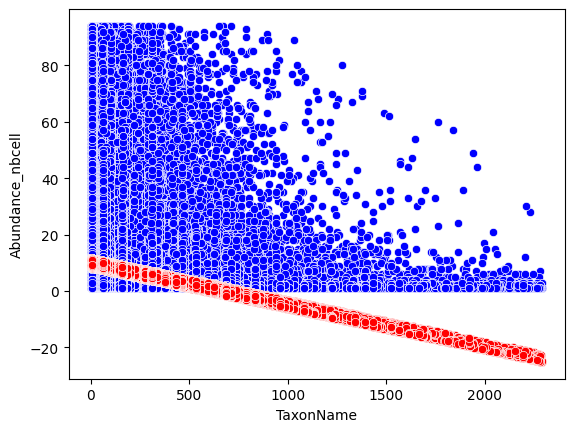

In [336]:
sns.scatterplot(x='TaxonName', y='Abundance_nbcell', color="blue", data=df_numeric)
sns.scatterplot(x='TaxonName', y='PrediccionesAbnbcellO', color="red", data=df_numeric)

*TotalAbundance_SamplingOperation*

In [318]:
Vars_Indep= df_numeric[['SamplingOperations_code', 'CodeSite_SamplingOperations']]
Var_Dep= df_numeric['TotalAbundance_SamplingOperation']

In [319]:
model= LinearRegression()

In [320]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [321]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SamplingOperations_code', 'CodeSite_SamplingOperations'],
       dtype=object),
 'n_features_in_': 2,
 'coef_': array([-2.11707005e-05,  2.16515197e-04]),
 'rank_': 2,
 'singular_': array([17408217.60705897,  2293720.30218036]),
 'intercept_': np.float64(405.1294134508698)}

In [322]:
model.score(Vars_Indep,Var_Dep)

0.004081333826560507

In [323]:
y_pred= model.predict(X=df_numeric[['SamplingOperations_code', 'CodeSite_SamplingOperations']])
y_pred

array([404.90858201, 404.64464556, 404.89900123, ..., 404.53745315,
       405.21506376, 405.52983959], shape=(1643872,))

In [324]:
df_numeric.insert(0, 'PrediccionesTotalAb0', y_pred)
df_numeric

,PrediccionesTotalAb0,PrediccionesAbnbcellO,PrediccionesDateSamplingO,PrediccionesCodeSiteO,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,404.908582,-14.424139,505.531550,2633.393789,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,404.644646,-14.689725,490.416792,2495.645562,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,404.899001,2.242015,478.025541,2267.481776,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,406.434422,1.032745,461.273552,1650.918446,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,405.055119,1.756580,462.199914,2019.900323,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643867,405.468993,-11.187866,435.179959,1559.036404,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,405.392961,-10.233307,470.880025,2045.803561,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,404.537453,-9.149154,496.172275,2598.762688,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,405.215064,-11.196502,429.402466,1555.684711,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [325]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                             Correlación simple  Coeficiente múltiple
SamplingOperations_code               -0.028288             -0.000021
CodeSite_SamplingOperations            0.048809              0.000217


<Axes: xlabel='SamplingOperations_code', ylabel='TotalAbundance_SamplingOperation'>

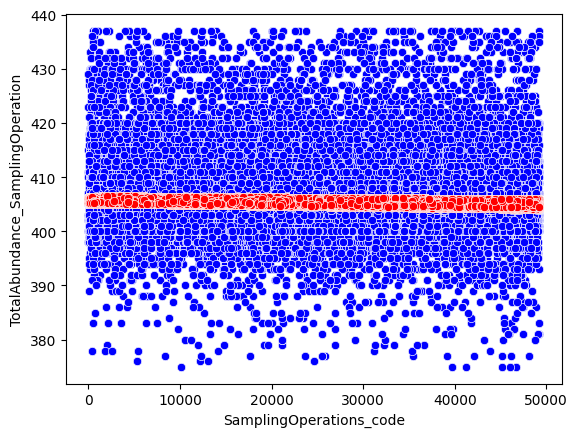

In [337]:
sns.scatterplot(x='SamplingOperations_code', y='TotalAbundance_SamplingOperation', color="blue", data=df_numeric)
sns.scatterplot(x='SamplingOperations_code', y='PrediccionesTotalAb0', color="red", data=df_numeric)

*Abundance_pm*

In [326]:
Vars_Indep= df_numeric[['SamplingOperations_code', 'TaxonName', 'TaxonCode']]
Var_Dep= df_numeric['Abundance_pm']

In [327]:
model= LinearRegression()

In [328]:
model.fit(X=Vars_Indep, y=Var_Dep)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [329]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['SamplingOperations_code', 'TaxonName', 'TaxonCode'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.0001592 , -0.01812906, -0.01812906]),
 'rank_': 2,
 'singular_': array([1.73988114e+07, 2.63951039e+05, 1.12274072e-09]),
 'intercept_': np.float64(20.821032069264305)}

In [330]:
model.score(Vars_Indep,Var_Dep)

0.03002593774266893

In [331]:
y_pred= model.predict(X=df_numeric[['SamplingOperations_code', 'TaxonName', 'TaxonCode']])
y_pred

array([-35.67549357, -36.336499  ,   5.5160871 , ..., -22.63530328,
       -27.73087189, -27.39193149], shape=(1643872,))

In [332]:
df_numeric.insert(0, 'PrediccionesAbpm0', y_pred)
df_numeric

,PrediccionesAbpm0,PrediccionesTotalAb0,PrediccionesAbnbcellO,PrediccionesDateSamplingO,PrediccionesCodeSiteO,PrediccionesSamplingO,PrediccionesTcode0,PrediccionesTname0,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,-35.675494,404.908582,-14.424139,505.531550,2633.393789,19819.007651,76.859892,76.859892,1706,1706,33667,2272,772,8.0,420.0,19.047619
1,-36.336499,404.644646,-14.689725,490.416792,2495.645562,16469.788297,92.309360,92.309360,1706,1706,29515,647,149,1.0,404.0,2.475248
2,5.516087,404.899001,2.242015,478.025541,2267.481776,17332.796082,99.469815,99.469815,521,521,22522,1138,949,1.0,400.0,2.500000
3,2.506379,406.434422,1.032745,461.273552,1650.918446,26615.714355,117.206454,117.206454,521,521,3617,6381,499,2.0,400.0,5.000000
4,4.307905,405.055119,1.756580,462.199914,2019.900323,17295.910851,107.249570,107.249570,521,521,14933,1117,63,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643867,-27.709380,405.468993,-11.187866,435.179959,1559.036404,18225.070671,121.758186,121.758186,1342,1342,804,1647,12,1.0,412.0,2.427184
1643868,-25.333613,405.392961,-10.233307,470.880025,2045.803561,20172.958868,106.435612,106.435612,1342,1342,15727,2755,351,1.0,400.0,2.500000
1643869,-22.635303,404.537453,-9.149154,496.172275,2598.762688,16143.238417,89.066841,89.066841,1342,1342,32676,461,452,1.0,403.0,2.481390
1643870,-27.730872,405.215064,-11.196502,429.402466,1555.684711,16587.120116,112.010790,112.010790,1342,1342,669,461,245,7.0,400.0,17.500000


In [333]:
# Correlaciones simples de la variable dependiente con las independientes
corr_simple = df_numeric[Vars_Indep.columns.tolist() + [Var_Dep.name]].corr()[Var_Dep.name].drop(Var_Dep.name)

# Coeficientes de regresión múltiple
coef_mult = pd.Series(model.coef_, index=Vars_Indep.columns)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Correlación simple': corr_simple,
    'Coeficiente múltiple': coef_mult
})

print(comparacion)

                         Correlación simple  Coeficiente múltiple
SamplingOperations_code            0.079608              0.000159
TaxonName                         -0.161564             -0.018129
TaxonCode                         -0.161564             -0.018129


<Axes: xlabel='TaxonName', ylabel='Abundance_pm'>

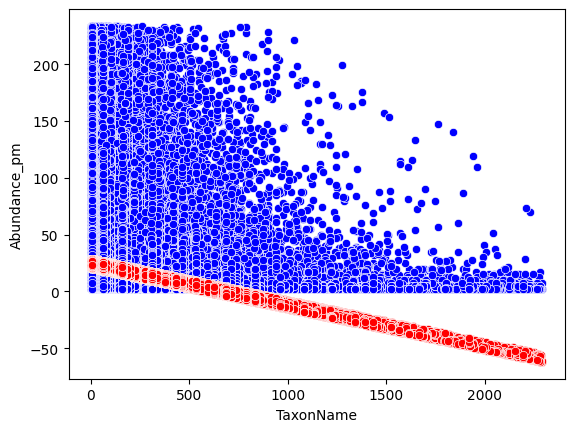

In [340]:
sns.scatterplot(x='TaxonName', y='Abundance_pm', color="blue", data=df_numeric)
sns.scatterplot(x='TaxonName', y='PrediccionesAbpm0', color="red", data=df_numeric)